In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class PatchExtract(layers.Layer):
    """Extract patches from input images with improved efficiency"""
    def __init__(self, patch_size):
        super(PatchExtract, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEmbedding(layers.Layer):
    """Enhanced patch embedding with learnable class token"""
    def __init__(self, num_patches, projection_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
        # Add learnable class token for better global representation
        self.class_token = self.add_weight(
            shape=(1, 1, projection_dim),
            initializer="random_normal",
            trainable=True,
            name="class_token"
        )

    def call(self, patch):
        batch_size = tf.shape(patch)[0]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        
        # Add class token to each batch
        class_tokens = tf.broadcast_to(self.class_token, [batch_size, 1, self.class_token.shape[-1]])
        
        # Project patches and add positional encoding
        encoded = self.projection(patch) + self.position_embedding(positions)
        
        # Concatenate class token
        encoded = tf.concat([class_tokens, encoded], axis=1)
        return encoded

class MultiHeadAttention(layers.Layer):
    """Improved multi-head attention with better initialization"""
    def __init__(self, embed_dim, num_heads=8, dropout_rate=0.1):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}"
            )
        
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.key_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.value_dense = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.combine_heads = layers.Dense(embed_dim, kernel_initializer="glorot_uniform")
        self.dropout = layers.Dropout(dropout_rate)

    def attention(self, query, key, value, training=None):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        weights = self.dropout(weights, training=training)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        
        attention, weights = self.attention(query, key, value, training=training)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

class TransformerBlock(layers.Layer):
    """Enhanced transformer block with improved regularization"""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(embed_dim, num_heads, rate)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),  # GELU often works better than ReLU
            layers.Dropout(rate),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Pre-norm architecture (often more stable)
        norm1 = self.layernorm1(inputs)
        attn_output = self.att(norm1, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = inputs + attn_output
        
        norm2 = self.layernorm2(out1)
        ffn_output = self.ffn(norm2, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return out1 + ffn_output

class UpsampleBlock(layers.Layer):
    """Enhanced upsampling block with skip connections support"""
    def __init__(self, filters, kernel_size=3, use_attention=False):
        super(UpsampleBlock, self).__init__()
        self.filters = filters
        self.use_attention = use_attention
        
        # Main upsampling path
        self.upsample = layers.Conv2DTranspose(
            filters, 2, strides=2, padding='same',
            kernel_initializer='he_normal'
        )
        self.conv1 = layers.Conv2D(
            filters, kernel_size, padding='same',
            kernel_initializer='he_normal'
        )
        self.conv2 = layers.Conv2D(
            filters, kernel_size, padding='same',
            kernel_initializer='he_normal'
        )
        
        # Normalization and activation
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()
        self.activation = layers.Activation('gelu')
        
        # Optional spatial attention
        if use_attention:
            self.spatial_attention = layers.Conv2D(1, 7, padding='same', activation='sigmoid')
        
    def call(self, x, training=None):
        x = self.upsample(x)
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = self.activation(x)
        
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = self.activation(x)
        
        # Apply spatial attention if enabled
        if self.use_attention:
            attention_weights = self.spatial_attention(x)
            x = x * attention_weights
            
        return x

def create_enhanced_vit_eye_segmentation_model(
    image_size=224,
    patch_size=16,
    num_patches=196,
    projection_dim=768,
    num_heads=12,
    transformer_units=[3072, 768],  # Increased FFN dimension
    transformer_layers=8,
    num_classes=4,
    dropout_rate=0.1,
    input_channels=1,
    use_attention_in_decoder=True
):
    """
    Enhanced Vision Transformer for Eye Segmentation
    
    Improvements:
    - Pre-norm transformer blocks
    - Class token for better global representation  
    - GELU activation instead of ReLU
    - Optional spatial attention in decoder
    - Better weight initialization
    """
    
    inputs = layers.Input(shape=(image_size, image_size, input_channels))
    
    # Create patches
    patches = PatchExtract(patch_size)(inputs)
    
    # Encode patches (now includes class token)
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)
    
    # Create multiple layers of the Transformer block
    for _ in range(transformer_layers):
        encoded_patches = TransformerBlock(
            projection_dim, num_heads, transformer_units[0], dropout_rate
        )(encoded_patches)
    
    # Layer normalization
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    
    # Remove class token before reshaping
    representation = representation[:, 1:, :]  # Remove first token (class token)
    
    # Reshape for decoder
    h = w = int(np.sqrt(num_patches))
    representation = layers.Reshape((h, w, projection_dim))(representation)
    
    # Enhanced decoder with optional attention
    x = UpsampleBlock(512, use_attention=use_attention_in_decoder)(representation)  # 14x14 -> 28x28
    x = UpsampleBlock(256, use_attention=use_attention_in_decoder)(x)               # 28x28 -> 56x56
    x = UpsampleBlock(128, use_attention=use_attention_in_decoder)(x)               # 56x56 -> 112x112
    x = UpsampleBlock(64, use_attention=use_attention_in_decoder)(x)                # 112x112 -> 224x224
    
    # Final segmentation layer with improved initialization
    outputs = layers.Conv2D(
        num_classes, 1, 
        activation='softmax', 
        name='segmentation',
        kernel_initializer='he_normal'
    )(x)
    
    model = keras.Model(inputs, outputs, name="Enhanced_ViT_Eye_Segmentation")
    return model

# Enhanced loss functions
# def focal_loss(gamma=2., alpha=0.25):
#     """Focal loss for handling class imbalance"""
#     def focal_loss_fixed(y_true, y_pred):
#         epsilon = tf.keras.backend.epsilon()
#         y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
#         # Convert sparse labels to one-hot
#         y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        
#         # Calculate focal loss
#         pt = tf.where(tf.equal(y_true_onehot, 1), y_pred, 1 - y_pred)
#         focal_weight = alpha * tf.pow(1 - pt, gamma)
#         focal_loss = -focal_weight * tf.log(pt)
        
#         return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))
    
#     return focal_loss_fixed

def dice_coefficient_enhanced(y_true, y_pred, smooth=1e-6, class_weights=None):
    """Enhanced dice coefficient with class weighting"""
    # Convert sparse labels to one-hot
    if len(y_true.shape) != len(y_pred.shape):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        y_true = tf.cast(y_true, tf.float32)
    
    # Flatten tensors
    y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
    y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
    
    # Calculate intersection and union for each class
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
    dice_per_class = (2. * intersection + smooth) / (union + smooth)
    
    # Apply class weights if provided
    if class_weights is not None:
        class_weights = tf.constant(class_weights, dtype=tf.float32)
        dice_per_class = dice_per_class * class_weights
    
    return tf.reduce_mean(dice_per_class)

# def combined_loss_enhanced(y_true, y_pred, alpha=0.3, beta=0.4, gamma=0.3):
#     """Enhanced combined loss: Focal + Dice + CE"""
#     # Focal loss for class imbalance
#     focal = focal_loss(gamma=2.0, alpha=0.25)(y_true, y_pred)
    
#     # Dice loss
#     dice_loss_val = 1 - dice_coefficient_enhanced(y_true, y_pred)
    
#     # Categorical crossentropy
#     y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
#     ce_loss = tf.keras.losses.categorical_crossentropy(y_true_onehot, y_pred)
    
#     return alpha * focal + beta * dice_loss_val + gamma * ce_loss

# Enhanced data loading with better augmentation
def enhanced_data_augmentation():
    """Create enhanced data augmentation pipeline"""
    def augment_data(image, label):
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            label = tf.image.flip_left_right(tf.expand_dims(label, -1))
            label = tf.squeeze(label, -1)
        
        # Random rotation (small angles)
        if tf.random.uniform(()) > 0.7:
            angle = tf.random.uniform((), -0.1, 0.1)  # ±5.7 degrees
            image = tf.image.rot90(image, k=tf.cast(angle * 4, tf.int32))
            label = tf.image.rot90(tf.expand_dims(label, -1), k=tf.cast(angle * 4, tf.int32))
            label = tf.squeeze(label, -1)
        
        # Random brightness and contrast
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_brightness(image, 0.15)
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_contrast(image, 0.85, 1.15)
        
        # Random noise
        if tf.random.uniform(()) > 0.8:
            noise = tf.random.normal(tf.shape(image), mean=0, stddev=0.02)
            image = tf.clip_by_value(image + noise, 0.0, 1.0)
        
        # Ensure image is in [0,1] range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    return augment_data

# Training configuration
def get_optimized_training_config():
    """Get optimized training configuration"""
    
    # Learning rate schedule
    def lr_schedule(epoch):
        """Custom learning rate schedule"""
        if epoch < 5:
            return 1e-4
        elif epoch < 15:
            return 5e-5
        elif epoch < 25:
            return 1e-5
        else:
            return 5e-6
    
    # Optimizer with weight decay
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=0.01,
        clipnorm=1.0
    )
    
    callbacks = [
        tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            'best_enhanced_vit_eye_model.h5',
            monitor='val_dice_coefficient_enhanced',
            save_best_only=True,
            mode='max',
            verbose=1,
            save_weights_only=False
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient_enhanced',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.7,
            patience=8,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return optimizer, callbacks

# Example usage
def create_and_compile_enhanced_model():
    """Create and compile the enhanced model"""
    
    model = create_enhanced_vit_eye_segmentation_model(
        image_size=224,
        patch_size=16,
        num_patches=196,
        projection_dim=768,
        num_heads=12,
        transformer_layers=8,
        num_classes=4,
        input_channels=1,
        dropout_rate=0.15,  # Slightly increased dropout
        use_attention_in_decoder=True
    )
    
    optimizer, callbacks = get_optimized_training_config()
    
    model.compile(
        optimizer=optimizer,
        loss= "sparse_categorical_crossentropy",
        metrics=['accuracy', dice_coefficient_enhanced]
    )
    
    return model, callbacks

# Enhanced visualization
def visualize_predictions_enhanced(model, images, labels, num_samples=4):
    """Enhanced visualization of model predictions"""
    
    # Make predictions
    predictions = model.predict(images[:num_samples])
    pred_masks = np.argmax(predictions, axis=-1)
    
    # Color mapping for classes
    colors = np.array([
        [0, 0, 0],        # Background - Black
        [255, 255, 255],  # Sclera - White  
        [0, 255, 0],      # Iris - Green
        [255, 0, 0]       # Pupil - Red
    ])
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        img = images[i].squeeze() if len(images[i].shape) == 3 else images[i]
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_colored = colors[labels[i]]
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        pred_colored = colors[pred_masks[i]]
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        # Overlay
        img_rgb = np.stack([img, img, img], axis=-1) if len(img.shape) == 2 else img
        if img_rgb.max() <= 1.0:
            img_rgb = (img_rgb * 255).astype(np.uint8)
        
        overlay = cv2.addWeighted(
            img_rgb.astype(np.uint8), 0.7, 
            pred_colored.astype(np.uint8), 0.3, 0
        )
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('enhanced_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

2025-09-17 22:47:13.734877: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-17 22:47:14.367052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758129434.622921   64229 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758129434.678139   64229 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758129435.377523   64229 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def load_grayscale_images_label_pairs(image_dir, label_dir, step=0, step_size=1000, 
                                    target_size=(224, 224), add_noise=False, 
                                    normalize_on_load=False):
    """
    Enhanced data loading with better error handling and validation
    """
    
    # Get sorted file lists
    image_files = sorted([f for f in os.listdir(image_dir) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    label_files = sorted([f for f in os.listdir(label_dir) 
                         if f.lower().endswith(('.npy', '.png', '.jpg', '.jpeg'))])
    
    print(f"Total images found: {len(image_files)}")
    print(f"Total labels found: {len(label_files)}")
    
    # Validate file count match
    if len(image_files) != len(label_files):
        print(f"⚠️  Warning: Mismatch in file counts - Images: {len(image_files)}, Labels: {len(label_files)}")
    
    # Calculate slice indices
    start_idx = step * step_size
    end_idx = min((step + 1) * step_size, len(image_files))
    
    print(f"📊 Loading batch {step + 1}: indices {start_idx} to {end_idx-1}")
    
    images = []
    labels = []
    failed_files = []
    
    # Process the subset
    for i, (img_file, label_file) in enumerate(zip(
        image_files[start_idx:end_idx], 
        label_files[start_idx:end_idx]
    )):
        try:
            # Load grayscale image
            img_path = os.path.join(image_dir, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                print(f"❌ Could not load image: {img_file}")
                failed_files.append(img_file)
                continue
            
            # Resize image
            img = cv2.resize(img, target_size)
            
            # Add channel dimension: (H, W) -> (H, W, 1)
            img = np.expand_dims(img, axis=-1)
            
            # Optional: normalize on load
            if normalize_on_load:
                img = img.astype(np.float32) / 255.0
            
            # Add noise if requested
            if add_noise:
                if normalize_on_load:
                    noise = np.random.normal(loc=0, scale=0.02, size=img.shape).astype(np.float32)
                    img = np.clip(img + noise, 0.0, 1.0)
                else:
                    noise = np.random.normal(loc=0, scale=10, size=img.shape).astype(np.float32)
                    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
            
            images.append(img)
            
            # Load label/mask
            label_path = os.path.join(label_dir, label_file)
            
            if label_file.endswith('.npy'):
                label = np.load(label_path)
            else:
                label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
                if label is None:
                    print(f"❌ Could not load label: {label_file}")
                    failed_files.append(label_file)
                    # Remove corresponding image
                    images.pop()
                    continue
            
            # Resize label to match target size
            label = cv2.resize(label, target_size, interpolation=cv2.INTER_NEAREST)
            
            # Ensure labels are integers and in valid range [0, 3]
            label = label.astype(np.int32)
            
            # Validate and clip label values
            unique_labels = np.unique(label)
            if np.max(unique_labels) > 3 or np.min(unique_labels) < 0:
                print(f"⚠️  Label {label_file} has invalid values {unique_labels}, clipping to [0,3]")
                label = np.clip(label, 0, 3)
            
            labels.append(label)
                
        except Exception as e:
            print(f"💥 Error processing {img_file}: {str(e)}")
            failed_files.append(img_file)
            # Remove corresponding image if it was added
            if len(images) > len(labels):
                images.pop()
            continue
    
    # Final validation
    if len(images) != len(labels):
        min_len = min(len(images), len(labels))
        images = images[:min_len]
        labels = labels[:min_len]
        print(f"⚠️  Trimmed to {min_len} matching pairs")
    
    if len(images) == 0:
        raise ValueError("No valid image-label pairs were loaded!")
    
    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32 if normalize_on_load else np.uint8)
    labels = np.array(labels, dtype=np.int32)
    
    return images, labels

In [3]:
def complete_training_pipeline(model, images, labels, epochs=15, batch_size=4, 
                             test_size=0.2, enhanced_augmentation=True, 
                             verbose_evaluation=True):
    
    

    X_train, X_val, y_train, y_val = train_test_split(
        images, labels, 
        test_size=test_size, 
        random_state=42
    )

    
    def enhanced_augment_data(image, label):
        """Enhanced data augmentation"""
        # Random horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            label = tf.image.flip_left_right(tf.expand_dims(label, -1))
            label = tf.squeeze(label, -1)
        
        if enhanced_augmentation:
            # Random brightness and contrast
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_brightness(image, 0.15)
            if tf.random.uniform(()) > 0.6:
                image = tf.image.random_contrast(image, 0.85, 1.15)
            
            # Random noise
            if tf.random.uniform(()) > 0.8:
                noise = tf.random.normal(tf.shape(image), mean=0, stddev=0.02)
                image = tf.clip_by_value(image + noise, 0.0, 1.0)
            
            # Random gamma correction
            if tf.random.uniform(()) > 0.7:
                gamma = tf.random.uniform((), 0.8, 1.2)
                image = tf.pow(image, gamma)
        
        # Ensure image is in [0,1] range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    # Create training dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=min(1000, len(X_train)), seed=42)
    # train_dataset = train_dataset.map(enhanced_augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    # Create validation dataset (no augmentation)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

    _, callbacks = create_and_compile_enhanced_model()  # Just to get callbacks
    
    # Update the checkpoint path to be unique for this batch
    for callback in callbacks:
        if isinstance(callback, tf.keras.callbacks.ModelCheckpoint):
            callback.filepath = f'best_enhanced_vit_eye_model_batch_{step if "step" in globals() else "current"}.h5'
    
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    def evaluate_model_enhanced(model, X_val, y_val, batch_size=4):
        """Enhanced model evaluation with detailed metrics"""
        print("🔍 Making predictions on validation set...")
        
        # Make predictions
        predictions = model.predict(X_val, batch_size=batch_size, verbose=1)
        pred_masks = np.argmax(predictions, axis=-1)
        
        # Calculate metrics per class
        num_classes = 4
        class_names = ['Background', 'Sclera', 'Iris', 'Pupil']
        
        print("\n📊 Per-class Dice Coefficients:")
        class_dice_scores = []
        
        for i in range(num_classes):
            true_class = (y_val == i).astype(np.float32)
            pred_class = (pred_masks == i).astype(np.float32)
            
            intersection = np.sum(true_class * pred_class)
            union = np.sum(true_class) + np.sum(pred_class)
            
            if union == 0:
                dice = 1.0 if intersection == 0 else 0.0
            else:
                dice = (2. * intersection) / union
            
            class_dice_scores.append(dice)
            print(f"  {class_names[i]:<12}: {dice:.4f}")
        
        # Overall metrics
        mean_dice = np.mean(class_dice_scores)
        accuracy = np.mean(pred_masks == y_val)
        
        print(f"\n📊 Overall Metrics:")
        print(f"  Mean Dice:     {mean_dice:.4f}")
        print(f"  Pixel Accuracy: {accuracy:.4f}")
        
        # Class distribution in predictions vs ground truth
        print(f"\n📊 Class Distribution Comparison:")
        total_pixels = y_val.size
        
        for i, class_name in enumerate(class_names):
            true_pct = (np.sum(y_val == i) / total_pixels) * 100
            pred_pct = (np.sum(pred_masks == i) / total_pixels) * 100
            print(f"  {class_name:<12}: True {true_pct:5.1f}% | Pred {pred_pct:5.1f}%")
        
        return pred_masks, {
            'class_dice_scores': class_dice_scores,
            'mean_dice': mean_dice,
            'accuracy': accuracy
        }
    
    if verbose_evaluation:
        pred_masks, eval_metrics = evaluate_model_enhanced(model, X_val, y_val, batch_size)
        eval_results = (X_val, y_val, pred_masks, eval_metrics)
    else:
        # Quick evaluation
        val_loss, val_acc, val_dice = model.evaluate(val_dataset, verbose=0)
        print(f"✅ Quick evaluation - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Dice: {val_dice:.4f}")
        eval_results = {'val_loss': val_loss, 'val_accuracy': val_acc, 'val_dice': val_dice}
    
    # ============================================================================
    # 5. VISUALIZATION
    # ============================================================================
    
    if verbose_evaluation and len(X_val) >= 4:
        print("\n🎨 Creating visualizations...")
        
        try:
            visualize_predictions_enhanced(model, X_val, y_val, pred_masks, num_samples=min(4, len(X_val)))
            print("✅ Visualizations saved!")
        except Exception as e:
            print(f"⚠️  Visualization failed: {str(e)}")
    
    print("\n" + "=" * 80)
    print("🎉 TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    
    return model, history, eval_results

In [ ]:
model, callbacks = create_and_compile_enhanced_model()

# 2. Your data paths
image_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'

# 3. Training loop with enhanced pipeline
for i in range(10):
    print(f"\n🔄 Processing batch {i+1}/3...")
    
    # Load data
    images, labels = load_grayscale_images_label_pairs(
        image_dir_path, label_dir_path,
        step=i, step_size=2000,
        target_size=(224, 224),
        add_noise=False,
        normalize_on_load=False  # Will be normalized in training pipeline
    )
    
    # Train with enhanced pipeline
    model, history, eval_results = complete_training_pipeline(
        model, images, labels,
        epochs=15,
        batch_size=4,
        test_size=0.2,
        enhanced_augmentation=True,
        verbose_evaluation=True
    )
    
    print(f"✅ Batch {i+1} completed!")

print("\n🎉 All batches completed successfully!")

I0000 00:00:1758129466.395721   64229 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



🔄 Processing batch 1/3...
Total images found: 27431
Total labels found: 27431
📊 Loading batch 1: indices 0 to 999

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/15


I0000 00:00:1758129509.425048   64854 service.cc:152] XLA service 0x770f00002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758129509.425090   64854 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-09-17 22:48:30.566854: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-17 22:48:32.643521: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1758129518.152972   64854 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-09-17 22:48:51.673985: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 208 bytes spi

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6696 - dice_coefficient_enhanced: 0.2452 - loss: 0.8733

2025-09-17 22:51:07.187170: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-09-17 22:51:09.789410: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 4920 bytes spill stores, 4916 bytes spill loads

2025-09-17 22:51:10.123236: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 588 bytes spill stores, 520 bytes spill loads

2025-09-17 22:51:10.193327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 412 bytes spill stores, 412 bytes spill loads

2025-09-17 22:51:10.468808: I external/local_xla/xla/stream_e

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 344ms/step - accuracy: 0.9966 - dice_coefficient_enhanced: 0.9800 - loss: 0.0085 - val_accuracy: 0.9951 - val_dice_coefficient_enhanced: 0.9749 - val_loss: 0.0138 - learning_rate: 5.0000e-05

Epoch 10: LearningRateScheduler setting learning rate to 5e-05.
Epoch 10/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9970 - dice_coefficient_enhanced: 0.9811 - loss: 0.0075
Epoch 10: val_dice_coefficient_enhanced improved from 0.97491 to 0.97498, saving model to best_enhanced_vit_eye_model_batch_current.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 330ms/step - accuracy: 0.9970 - dice_coefficient_enhanced: 0.9811 - loss: 0.0075 - val_accuracy: 0.9949 - val_dice_coefficient_enhanced: 0.9750 - val_loss: 0.0148 - learning_rate: 5.0000e-05

Epoch 11: LearningRateScheduler setting learning rate to 5e-05.
Epoch 11/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9969 - dice_coefficient_enhanced: 0.9813 - loss: 0.0077
Epoch 11: val_dice_coefficient_enhanced improved from 0.97498 to 0.97596, saving model to best_enhanced_vit_eye_model_batch_current.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 335ms/step - accuracy: 0.9969 - dice_coefficient_enhanced: 0.9813 - loss: 0.0077 - val_accuracy: 0.9950 - val_dice_coefficient_enhanced: 0.9760 - val_loss: 0.0145 - learning_rate: 5.0000e-05

Epoch 12: LearningRateScheduler setting learning rate to 5e-05.
Epoch 12/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9970 - dice_coefficient_enhanced: 0.9828 - loss: 0.0073
Epoch 12: val_dice_coefficient_enhanced did not improve from 0.97596
200/200 ━━━━━━━━━━━━━━━━━━━━ 65s 327ms/step - accuracy: 0.9970 - dice_coefficient_enhanced: 0.9828 - loss: 0.0073 - val_accuracy: 0.9950 - val_dice_coefficient_enhanced: 0.9756 - val_loss: 0.0142 - learning_rate: 5.0000e-05

Epoch 13: LearningRateScheduler setting learning rate to 5e-05.
Epoch 13/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9971 - dice_coefficient_enhanced: 0.9833 - loss: 0.0070
Epoch 13: val_dice_coefficient_enhanced did not improve from 0.97596
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 3

200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 335ms/step - accuracy: 0.9972 - dice_coefficient_enhanced: 0.9834 - loss: 0.0068 - val_accuracy: 0.9952 - val_dice_coefficient_enhanced: 0.9771 - val_loss: 0.0140 - learning_rate: 5.0000e-05

Epoch 15: LearningRateScheduler setting learning rate to 5e-05.
Epoch 15/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9973 - dice_coefficient_enhanced: 0.9836 - loss: 0.0067
Epoch 15: val_dice_coefficient_enhanced improved from 0.97714 to 0.97731, saving model to best_enhanced_vit_eye_model_batch_current.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 344ms/step - accuracy: 0.9973 - dice_coefficient_enhanced: 0.9836 - loss: 0.0067 - val_accuracy: 0.9951 - val_dice_coefficient_enhanced: 0.9773 - val_loss: 0.0148 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 15.
🔍 Making predictions on validation set...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step

📊 Per-class Dice Coefficients:
  Background  : 0.9978
  Sclera      : 0.9773
  Iris        : 0.9876
  Pupil       : 0.9696

📊 Overall Metrics:
  Mean Dice:     0.9831
  Pixel Accuracy: 0.9951

📊 Class Distribution Comparison:
  Background  : True  83.4% | Pred  83.3%
  Sclera      : True   8.6% | Pred   8.7%
  Iris        : True   7.5% | Pred   7.5%
  Pupil       : True   0.6% | Pred   0.6%

🎨 Creating visualizations...
⚠️  Visualization failed: visualize_predictions_enhanced() got multiple values for argument 'num_samples'

🎉 TRAINING PIPELINE COMPLETED SUCCESSFULLY!
✅ Batch 3 completed!

🎉 All batches completed successfully

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


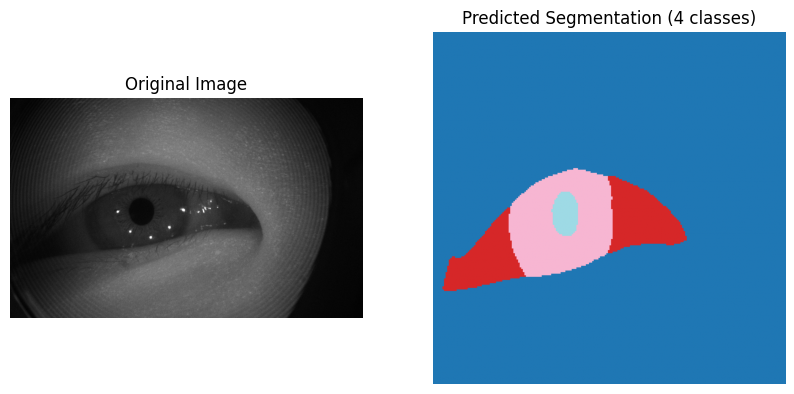

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the path to the image you want to predict
image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/S_175/110.png'
# image_path = '/home/yasas/GazeEstimation/412.jpg'

# Load the image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Shape: (H, W)

# Resize to model's expected size (224x224)
img = cv2.resize(image, (224, 224))

# Add channel dimension: (224, 224) -> (224, 224, 1)
img = np.expand_dims(img, axis=-1)

# Add batch dimension: (224, 224, 1) -> (1, 224, 224, 1)
img = np.expand_dims(img, axis=0)

# Predict
predicted_mask = model.predict(img)

predicted_mask = np.argmax(predicted_mask, axis=-1)  # Shape: (1, 224, 224)

# Remove batch dimension
predicted_mask = predicted_mask[0]  # Shape: (224, 224)

# Plot original and predicted mask
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab20')  # tab20 gives distinct colors for classes
plt.title('Predicted Segmentation (4 classes)')
plt.axis('off')

plt.show()
